# ACC102 Mini Assignment: Big Tech Capital Efficiency Analysis

**Analytical Problem**:To explore the relationship between financial performance and stock market performance among three major technology companies (Apple, Microsoft, Google) from 2020 to 2024, and help investors make better investment decisions based on financial indicators.

**Target User**: Long-term equity investors evaluating Big Tech portfolio allocation.

**Data Source**: WRDS CRSP & Compustat, accessed [17 April 2026]

## 1. Import Required Libraries

Import WRDS for database access and pandas for data processing and visualization.

In [ ]:
import wrds
import pandas as pd

In [160]:
username = "zhouxuwen24"
db = wrds.Connection(wrds_username=username)

Loading library list...
Done


## 2. Extract Stock Market Data

Define query parameters for AAPL, MSFT, GOOGL and extract daily prices, 
returns, and volume from WRDS CRSP (2020-2024). Handle CRSP price adjustments 
by taking absolute values.

In [161]:
tickers= ("MSFT","AAPL" ,"GOOGL" )     
start_date = "2020-01-01"
selected_columns_stock= """
b.htsymbol,
a.date,
a.prc,
a.ret,
a.vol
"""

In [162]:
sql_query_stock = f"""
SELECT {selected_columns_stock}
FROM crsp.msf AS a
LEFT JOIN crsp.msfhdr AS b
    ON a.permno = b.permno
WHERE b.htsymbol IN {tickers}
AND a.date >= '{start_date}'
"""
print(sql_query_stock)



SELECT 
b.htsymbol,
a.date,
a.prc,
a.ret,
a.vol

FROM crsp.msf AS a
LEFT JOIN crsp.msfhdr AS b
    ON a.permno = b.permno
WHERE b.htsymbol IN ('MSFT', 'AAPL', 'GOOGL')
AND a.date >= '2020-01-01'



In [163]:
stock_data = db.raw_sql(sql_query_stock)
stock_data['prc'] = stock_data['prc'].abs()

## 3. Extract Financial Data

Query WRDS Compustat for annual fundamentals including revenue, net income, 
EBITDA, equity, and assets to support profitability and efficiency analysis.

In [164]:
selected_columns_fin = """
a.tic,
a.datadate,
a.revt,
a.ni,
a.ebitda,
a.epspi,
a.xrd,
a.ceq,
a.at
"""

In [165]:
sql_query_fin = f"""
SELECT {selected_columns_fin}
FROM comp.funda AS a
WHERE tic IN {tickers}
AND datadate >= '{start_date}'
AND datadate <= '2024-12-31'
AND datafmt = 'STD'
AND consol = 'C'
AND indfmt = 'INDL'
"""

In [166]:
print(sql_query_fin)
fin_data = db.raw_sql(sql_query_fin)


SELECT 
a.tic,
a.datadate,
a.revt,
a.ni,
a.ebitda,
a.epspi,
a.xrd,
a.ceq,
a.at

FROM comp.funda AS a
WHERE tic IN ('MSFT', 'AAPL', 'GOOGL')
AND datadate >= '2020-01-01'
AND datadate <= '2024-12-31'
AND datafmt = 'STD'
AND consol = 'C'
AND indfmt = 'INDL'



## 4. Clean and Preprocess Data
Convert date fields to datetime format and extract year for annual aggregation, enabling consistent time-based analysis across stock and financial datasets.


In [167]:
stock_data['date'] = pd.to_datetime(stock_data['date'])
fin_data['datadate'] = pd.to_datetime(fin_data['datadate'])

In [168]:
stock_data['year'] = stock_data['date'].dt.year
fin_data['year'] = fin_data['datadate'].dt.year

## 5. Stock Performance Aggregation and Visualization

Aggregate daily stock data to annual metrics including average price, mean return, total volume, and return volatility. Rename 'htsymbol' to 'company' for cross-dataset consistency. Visualize price trends and annual returns to compare market performance and risk profiles across AAPL, MSFT, and GOOGL.

In [169]:
stock_summary = stock_data.groupby(['htsymbol', 'year']).agg(
     avg_price=('prc', 'mean'),
     avg_return=('ret', 'mean'),
     total_volume=('vol', 'sum'),
     vol_return=('ret','std'),
 ).reset_index()

stock_summary=stock_summary.rename(columns={'htsymbol':'company'})
 
print("=== Stock Performance Summary ===")
stock_summary

=== Stock Performance Summary ===


,company,year,avg_price,avg_return,total_volume,vol_return
0,AAPL,2020,237.015831,0.057218,185365681.0,0.114836
1,AAPL,2021,141.688337,0.027034,228066911.0,0.064969
2,AAPL,2022,153.912498,-0.021214,220596076.0,0.095027
3,AAPL,2023,175.523332,0.035677,147829301.0,0.064925
4,AAPL,2024,208.964166,0.023962,142290151.0,0.056348
5,GOOGL,2020,1486.539998,0.02632,5044596.0,0.089119
6,GOOGL,2021,2501.820007,0.044655,3826772.0,0.065044
7,GOOGL,2022,1294.0975,-0.03756,37919288.0,0.077463
8,GOOGL,2023,119.8825,0.041915,81624032.0,0.080559
9,GOOGL,2024,164.754167,0.027322,68656901.0,0.055736


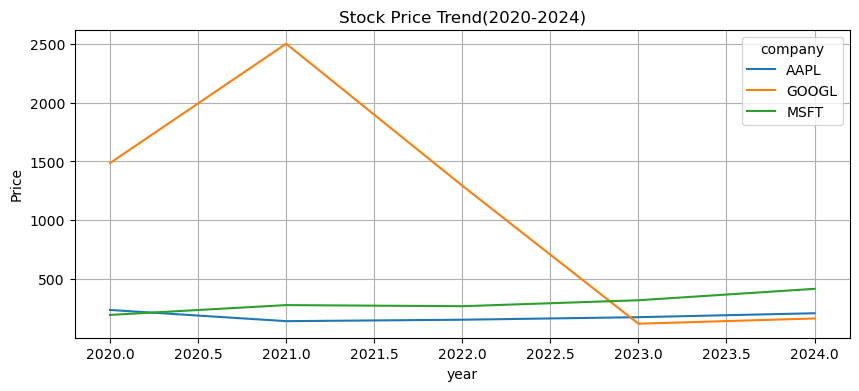

In [170]:
stock_price = stock_summary.pivot(index='year', columns='company', values='avg_price')
ax = stock_price.plot(kind='line', figsize=(10, 4), title='Stock Price Trend(2020-2024)')
ax.set_ylabel('Price') 
ax.grid(True)

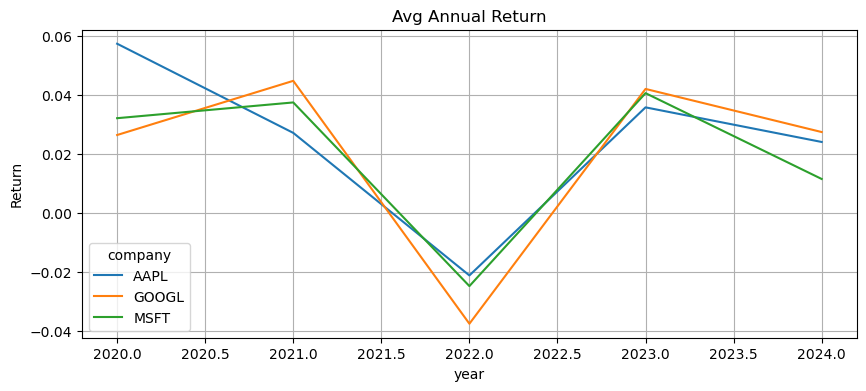

In [171]:
stock_ret = stock_summary.pivot(index='year', columns='company', values='avg_return')
ax = stock_ret.plot(kind='line', figsize=(10,4), title='Avg Annual Return')
ax.set_ylabel('Return')
ax.grid(True)

## 6. Financial Performance Aggregation and Visualization

Aggregate annual financial data and calculate profitability ratios including net profit margin, EBITDA margin, R&D intensity, ROA, and ROE. Visualize revenue trends and capital efficiency metrics to compare operational performance and shareholder return strategies across AAPL, MSFT, and GOOGL.

In [172]:
fin_summary = fin_data.groupby(['tic', 'year']).agg(
     revenue=('revt', 'sum'),
     net_income=('ni', 'sum'),
     ebitda=('ebitda', 'sum'),
     eps=('epspi', 'mean'),   
     rd_expense=('xrd', 'sum'),
     total_assets=('at', 'mean'),
     total_equity=('ceq','mean')
 ).reset_index()

fin_summary=fin_summary.rename(columns={'tic':'company'})

fin_summary['net_profit_margin'] = fin_summary['net_income'] / fin_summary['revenue']
fin_summary['ebitda_margin'] = fin_summary['ebitda'] / fin_summary['revenue']
fin_summary['rd_intensity'] = fin_summary['rd_expense'] / fin_summary['revenue']
fin_summary['roa'] = fin_summary['net_income'] / fin_summary['total_assets']
fin_summary['roe'] = fin_summary['net_income'] / fin_summary['total_equity']
fin_summary = fin_summary[['company', 'year','revenue', 'net_profit_margin', 'ebitda_margin', 'rd_intensity', 'roa','roe']]
fin_summary = fin_summary.round(3)

print("\n=== Financial Performance Summary ===")
fin_summary


=== Financial Performance Summary ===


,company,year,revenue,net_profit_margin,ebitda_margin,rd_intensity,roa,roe
0,AAPL,2020,274515.0,0.209,0.277,0.068,0.177,0.879
1,AAPL,2021,365817.0,0.259,0.324,0.06,0.27,1.501
2,AAPL,2022,394328.0,0.253,0.325,0.067,0.283,1.97
3,AAPL,2023,383285.0,0.253,0.32,0.078,0.275,1.561
4,AAPL,2024,391035.0,0.24,0.336,0.08,0.257,1.646
5,GOOGL,2020,182527.0,0.221,0.301,0.151,0.126,0.181
6,GOOGL,2021,257637.0,0.295,0.354,0.123,0.212,0.302
7,GOOGL,2022,282836.0,0.212,0.32,0.14,0.164,0.234
8,GOOGL,2023,307394.0,0.24,0.32,0.148,0.183,0.263
9,GOOGL,2024,350018.0,0.286,0.367,0.141,0.222,0.311


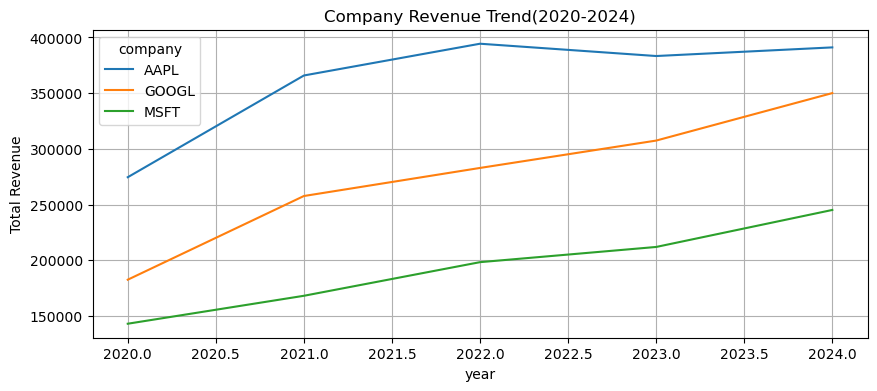

In [173]:
revenue_fin = fin_summary.pivot(index='year', columns='company', values='revenue')
ax = revenue_fin.plot(kind='line', figsize=(10, 4), title='Company Revenue Trend(2020-2024)')
ax.set_ylabel('Total Revenue')
ax.grid(True)

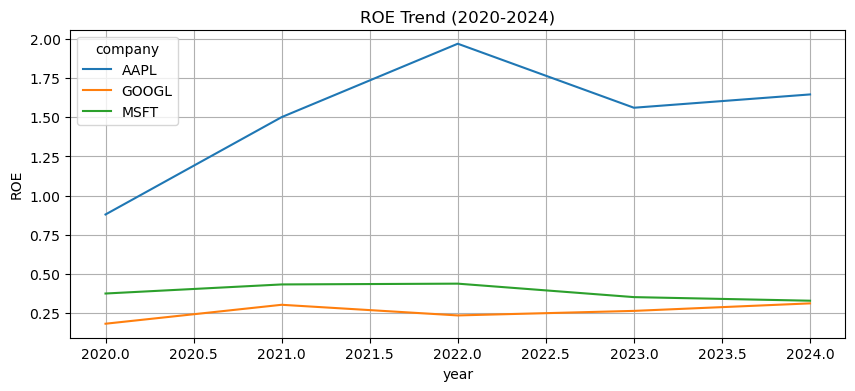

In [174]:
roe_fin = fin_summary.pivot(index='year', columns='company', values='roe')
ax = roe_fin.plot(kind='line', figsize=(10, 4),title='ROE Trend (2020-2024)')
ax.set_ylabel('ROE')
ax.grid(True)

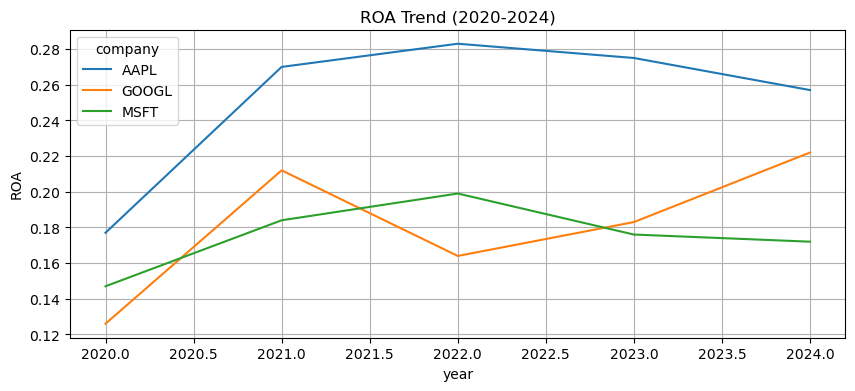

In [175]:
roa_fin = fin_summary.pivot(index='year', columns='company', values='roa')
ax = roa_fin.plot(kind='line', figsize=(10, 4),title='ROA Trend (2020-2024)')
ax.set_ylabel('ROA')
ax.grid(True)

## 7. Data Integration and Risk-Adjusted Metrics

Merge stock performance and financial datasets on company and year. Calculate return-risk ratio by dividing average return by volatility to enable comparison of risk-adjusted returns across firms.

In [176]:
final_table = pd.merge(
     stock_summary,
     fin_summary,
     on=['company', 'year']
 )
 
final_table['return_risk_ratio'] = final_table['avg_return'] / final_table['vol_return']
final_table = final_table.round(3)

print("\n=== Combined Final Table ===")
final_table


=== Combined Final Table ===


,company,year,avg_price,avg_return,total_volume,vol_return,revenue,net_profit_margin,ebitda_margin,rd_intensity,roa,roe,return_risk_ratio
0,AAPL,2020,237.016,0.057,185365681.0,0.115,274515.0,0.209,0.277,0.068,0.177,0.879,0.498
1,AAPL,2021,141.688,0.027,228066911.0,0.065,365817.0,0.259,0.324,0.06,0.27,1.501,0.416
2,AAPL,2022,153.912,-0.021,220596076.0,0.095,394328.0,0.253,0.325,0.067,0.283,1.97,-0.223
3,AAPL,2023,175.523,0.036,147829301.0,0.065,383285.0,0.253,0.32,0.078,0.275,1.561,0.55
4,AAPL,2024,208.964,0.024,142290151.0,0.056,391035.0,0.24,0.336,0.08,0.257,1.646,0.425
5,GOOGL,2020,1486.54,0.026,5044596.0,0.089,182527.0,0.221,0.301,0.151,0.126,0.181,0.295
6,GOOGL,2021,2501.82,0.045,3826772.0,0.065,257637.0,0.295,0.354,0.123,0.212,0.302,0.687
7,GOOGL,2022,1294.098,-0.038,37919288.0,0.077,282836.0,0.212,0.32,0.14,0.164,0.234,-0.485
8,GOOGL,2023,119.883,0.042,81624032.0,0.081,307394.0,0.24,0.32,0.148,0.183,0.263,0.52
9,GOOGL,2024,164.754,0.027,68656901.0,0.056,350018.0,0.286,0.367,0.141,0.222,0.311,0.49


In [177]:
db.close()